# Scryfall Tags: Multi-Label Classification  
__Objective:__ Since the scryfall tags are in essence a collection of multiple labels for each card, this problem is at it's core a mutli-label classification task. However, given that there are nearly as many labels as cards, it will be easier to frame this as a seq2seq problem.

## Packages and Data

In [1]:
# # UNCOMMENT if operating in google colab

# ## mount to drive
# from google.colab import drive
# drive.mount('/content/gdrive', force_remount=True)

# ## ensure current directory is identified
# import os
# PROJECT_PATH = '/content/gdrive/MyDrive/data_science/scryfall-llm-sandbox'
# os.chdir(f"{PROJECT_PATH}/notebooks")
# print(f"Current Directory: {os.getcwd()}")

# # check that GPUs are available
# import torch
# print(f'GPUs Available?: {torch.cuda.is_available()}')
# print(f"Device Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU'}")

In [2]:
# connect project directory
import sys
from pathlib import Path
dir = str(Path(Path.cwd()).parents[0])
if dir not in sys.path:
    sys.path.append(dir)

# ## UNCOMMENT if operating in gdrive colab
# gdir = str(Path.cwd()) +  '/MyDrive/data_science/scryfall-llm-sandbox'
# if gdir not in sys.path:
#   sys.path.append(gdir)

In [3]:
# params

## data gathering
from src.config import BUILD_DATASET, TASK, TAG_SIZE, DATASET_SIZE_N, TEST_SIZE_N
from src.config import MAX_INPUT_LENGTH, MAX_TARGET_LENGTH

## modeling
from src.config import MODEL_NAME, TRAIN_MODEL
from src.config import BATCH_SIZE, LEARNING_RATE, WEIGHT_DECAY, NUM_EPOCHS
from src.config import GENERATION_MAX_LENGTH, GENERATION_NUM_BEAMS

## save model
from src.config import OUTPUT_DIR

In [4]:
# packages

## load from project directory
from src.data_gathering.scryfall_dataset import ScryfallDataset
if TASK == 'seq2seq':
    from src.fine_tuning.fine_tune_seq2seq import FineTuneLLM
elif TASK == 'multi_label_classification':
    from src.fine_tuning.fine_tune_multi_lab import FineTuneLLM

In [5]:
# get data
sf = ScryfallDataset(task = TASK)

## build dataset as needed
if BUILD_DATASET:
    sf.build_dataset(
        tag_path = '../reports/scryfall_tags.json',
        train_size_pct = 0.8,
        truncate_dataset = DATASET_SIZE_N,
        test_size_n = TEST_SIZE_N,
        top_n_tags = TAG_SIZE
    )

## load dataset
sf.load_hf_dataset(
    train_path = f'../data/scryfall_{TASK}_train.json',
    val_path = f'../data/scryfall_{TASK}_val.json',
    test_path = f'../data/scryfall_{TASK}_test.json'
)

Scryfall Tag Question Answering Dataset Built
	Train Records = 6717
	Validation Records = 1680
	Test Records = 50
	Records saved to...
		../data/scryfall_multi_label_classification_train.json
		../data/scryfall_multi_label_classification_val.json
		../data/scryfall_multi_label_classification_test.json
	NOTE: This method does not create the huggingface dataset object. Run load_dataset() for that.
Scryfall Tag Multi Label Classification Dataset Loaded
	Train Records = 6717
	Val Records = 1680
	Test Records = 50
	Count Unique Tags = 300


From the below EDA, we can see that choosing between 300 and 400 tags is likely to be the most learnable scenario. That gives us 20-30 examples per tag at minimum.

Percentile 80 = 3.0 (n = 1476)
Percentile 81 = 3.0 (n = 1476)
Percentile 82 = 3.0 (n = 1476)
Percentile 83 = 4.0 (n = 1208)
Percentile 84 = 4.0 (n = 1208)
Percentile 85 = 4.0 (n = 1208)
Percentile 86 = 5.0 (n = 1047)
Percentile 87 = 5.0 (n = 1047)
Percentile 88 = 6.0 (n = 942)
Percentile 89 = 7.0 (n = 867)
Percentile 90 = 8.0 (n = 778)
Percentile 91 = 9.0 (n = 736)
Percentile 92 = 10.0 (n = 680)
Percentile 93 = 13.0 (n = 568)
Percentile 94 = 16.0 (n = 491)
Percentile 95 = 20.0 (n = 416)
Percentile 96 = 27.0 (n = 338)
Percentile 97 = 36.0 (n = 250)
Percentile 98 = 54.0 (n = 170)
Percentile 99 = 110.94000000000051 (n = 86)


array([17, 24, 33, ...,  1,  1,  1], shape=(8507,))

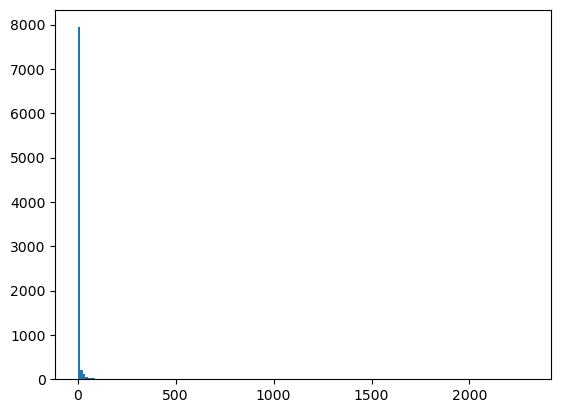

In [6]:
import numpy as np
import matplotlib.pyplot as plt
def tag_count_eda(data):
    arr = np.array(list(data.values()))
    for i in range(80, 100, 1):
        x = np.percentile(arr, i)
        n = len(arr[arr > x])
        print(f'Percentile {i} = {x} (n = {n})')
    
    fig = plt.hist(arr, bins = 'auto')
    return arr

tag_count_eda(data = sf.tag_counts)

## Modeling

__distilbert-base-uncased__  
trainable params: 1,121,779 || all params: 68,458,982 || trainable%: 1.6386  
best training loss (20 epochs) = 0.060179  
best validation loss (20 epochs) = 0.153198  

__microsoft/deberta-v3-base__  
trainable params: 1,268,467 || all params: 186,074,342 || trainable%: 0.6817  _<-- with value layers_  
trainable params: 973,555 || all params: 185,779,430 || trainable%: 0.5240 _<-- without value layers_  
best training loss (20 epochs) = 0.238682  
best validation loss (20 epochs) = 0.303357  
achieved 0.267833 val loss on 5e-5 learning rate, then early stopping at epoch 15.

### Fine Tune

In [7]:
# Multi Label Classification Fine Tuning
if TRAIN_MODEL:
    tagger_ft = FineTuneLLM(
        model_name = MODEL_NAME,
        dataset = sf.dataset,
        n_labels = len(sf.unique_tags),
        label2id = sf.label2id,
        id2label = sf.id2label,
        class_weights = sf.class_weights
    )

    tagger_ft.prepare_data(
        max_input_length = MAX_INPUT_LENGTH
    )

    tagger_ft.train(
        batch_size = BATCH_SIZE,
        n_epochs = NUM_EPOCHS,
        learning_rate = LEARNING_RATE,
        weight_decay = WEIGHT_DECAY,
        # output_dir = f'{PROJECT_PATH}/models/scryfall_auto_tagger' # uncomment if in google colab
        output_dir = f'../models/scryfall_auto_tagger'
    )

what if we try a lower tag count. Top 300 instead of Top 500.

### Evaluate Fine Tuning

In [8]:
# SEQ2SEQ fine tune the model
if TASK == 'seq2seq':
    tagger_ft = FineTuneLLM(
        model_name = MODEL_NAME,
        dataset = sf.dataset
    )
    tagger_ft.prepare_data(
        max_input_length = MAX_INPUT_LENGTH,
        max_target_length = MAX_TARGET_LENGTH
    )
    tagger_ft.train(
        batch_size = BATCH_SIZE,
        n_epochs = NUM_EPOCHS,
        learning_rate = LEARNING_RATE,
        weight_decay = WEIGHT_DECAY,
        generation_max_length = GENERATION_MAX_LENGTH,
        generation_num_beams = GENERATION_NUM_BEAMS,
        # output_dir = f'{PROJECT_PATH}/models/scryfall_auto_tagger' # uncomment if in google colab
        output_dir = f'../models/scryfall_auto_tagger'
    )

In [9]:
if (TRAIN_MODEL) and (TASK == 'seq2seq'):
    # Assuming 'tagger' is your FineTuneLLM instance
    from src.utils.debug_autotagger import debug_autotagger_outputs
    debug_autotagger_outputs(tagger_ft, sf.dataset, num_samples=10)

In [10]:
if (TRAIN_MODEL) and (TASK == 'multi_label_classification'):
    import numpy as np
    test_ids = list(sf.dataset['test']['id'])
    sample_ids = np.random.choice(test_ids, 5, replace = False)
    for card in sf.dataset['test']:
        if card['id'] in sample_ids:
            pred = tagger_ft.generate_tags(card_text = card['document'])
            print(f'Card ID {card["id"]}')
            print(f'\tActual Tags = {sorted(card["tags"])}')
            print(f'\tPredicted Tags = {sorted(pred)}')

In [11]:
# save the epoch training log
if TRAIN_MODEL:
    out_path = f'../reports/fine_tune_{MODEL_NAME.replace("/", "__")}_training_log.csv'
    tagger_ft.training_log_history.to_csv()
    print(f'Saved training log to {out_path}')

### Save To Huggingface Hub

In [12]:
# # UNCOMMENT TO login to the hugging face
# from huggingface_hub import notebook_login
# # with open('../huggingface_token.txt', 'r') as f:
# #     token = f.read()

# notebook_login()

In [13]:
# # UNCOMMENT TO upload to huggingface hub
# from huggingface_hub import get_full_repo_name
# # from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
# repo_id = get_full_repo_name(OUTPUT_DIR)
# tagger.model.push_to_hub(repo_id)
# tagger.tokenizer.push_to_hub(repo_id)

## Load Model From Huggingface

In [14]:
# load model and use it to test results
from src.modeling.auto_tagger_multi_lab import ScryfallTaggerFromPretrained
tagger = ScryfallTaggerFromPretrained(
    base_model_name = MODEL_NAME,
    n_labels = len(sf.unique_tags),
    output_dir = OUTPUT_DIR,
    id2label = sf.id2label,
    label2id = sf.label2id
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [18]:
# use the pretrained model on the test set
if TASK == 'multi_label_classification':
    import numpy as np
    test_ids = list(sf.dataset['test']['id'])
    sample_ids = np.random.choice(test_ids, 5, replace = False)
    for card in sf.dataset['test']:
        if card['id'] in sample_ids:
            pred = tagger.generate_tags(
                card_text = card['document'], 
                threshold = 0.7, # 0.7 was the best result from training
                cap_tags = False # the default
            )
            print(f'Card ID {card["id"]}')
            print(f'\tActual Tags = {sorted(card["tags"])}')
            print(f'\tPredicted Tags = {sorted(pred)}')

Card ID 3121
	Actual Tags = ['repeatable creature tokens']
	Predicted Tags = ['repeatable creature tokens', 'unprinted token']
Card ID 3763
	Actual Tags = ['cast trigger-you', 'mana value matters', 'pair-commander', 'removal-nonland', 'repeatable crime', 'repeatable removal', 'spot removal']
	Predicted Tags = ['intervening if clause', 'mana value matters', 'removal-bounce', 'removal-nonland', 'removal-permanent', 'repeatable crime', 'repeatable removal', 'spot removal', 'triggered ability']
Card ID 4211
	Actual Tags = ['attack trigger', 'burn creature', 'evasion', 'pinger', 'repeatable crime', 'repeatable removal', 'spot removal', 'synergy-attacker-self']
	Predicted Tags = ['alliteration', 'attack trigger', 'burn creature', 'evasion', 'pinger', 'repeatable crime', 'repeatable removal', 'spot removal', 'synergy-attacker-self']
Card ID 4426
	Actual Tags = ['cantrip', 'hand-neutral', 'hate-white', 'removal-creature', 'removal-destroy', 'single english word name', 'single target instant/so

## Output

## Graveyard

In [16]:
# # upload the model to the huggingface hub
# from huggingface_hub import Repository
# from huggingface_hub import get_full_repo_name

# ## define the repo locally
# ## NOTE: Be sure to create OUTPUT_DIR in the hub manually first
# repo_name = get_full_repo_name(OUTPUT_DIR)
# repo = Repository(OUTPUT_DIR, clone_from = repo_name)

# ## save to hub
# tagger.save_to_huggingface_hub(
#     output_dir = OUTPUT_DIR,
#     repo = repo,
#     commit_message = f'Fine-tuned {MODEL_NAME} on scryfall tags.'
# )